# 快速验证
这个demo主要提供部分样板代码，方便快速验证新知识点

## 修改历史
验证涉及的新知识点记录在这里，作为备忘

- StateSchema的每一个属性都是channel，通道会依据metadata中指定的归约器进行状态更新
- channel的默认（即不指定归约器）行为是 覆盖 ，即新值覆盖旧值
- 使用operator.add作为归约器时，如果是list，会把所有并行节点的计算结果追加到list末尾，如果是数字类型，那么会依次对每个节点的返回值做add
- Annotated是py的预置类型，为已有类型添加元数据，langgraph用它来指定归约器
- 自定义reducer可以定制符合业务规则的归约逻辑；尽量保持幂等性；自定义reducer可以根据业务需要实现不同的合并策略；同样可以
- list(set(list_a, list_b))可以实现去重合并
- RemoveMessage是langchain_core暴露的MessagesState操作函数，用于删除指定id的消息


### py知识点
- list[-n:] : 保留最新的n个元素,如果不带:，表示读取从后往前的第n个元素
- {**args1, **args2}: 深度合并两个字典，同名元素会覆盖



## Error

Error:  InvalidUpdateError occurred: At key 'foo': Can receive only one value per step. Use an Annotated key to handle multiple values.
Reason: 使用默认归约器的覆盖规则，但是出现节点并行更新，导致更新冲突，不知道该保留哪一个

In [111]:
# 创建glm4.7的客户端实例，一般不用改
from langchain_openai import ChatOpenAI


glm_client = ChatOpenAI(
    model="glm-4.7",
    api_key="d1de7475090740ebb6c887167a6a8b98.2WUSfYbmgQwYLKF4",
    base_url="https://open.bigmodel.cn/api/paas/v4/",  # 智谱OpenAI兼容地址，末尾斜杠不能丢
)



In [112]:
# 主要修改部分： 这部分构建图，可以按需修改图的状态schema及节点和图结构
import operator
from typing import Annotated, TypedDict

from langgraph.graph import END, START, StateGraph


# # add不能处理None，定制归约器来兼容None的场景
# def cust_reducer(old: list | None, new: list | None) -> list:
#     if not old:
#         old = []
#     if not new:
#         new = []

#     return list(set(old + new))


def keep_last_n( n: int) -> list:
    def reducer(old:list, new:list)->list:
        res = old + new;
        if len(res) <= n:
                return res
        return res[-n:]
    return reducer


class State(TypedDict):
    foo: Annotated[list[int], keep_last_n(1)]


def node_1(state: State):
    print(f"node value is {state['foo']}")
    return {"foo": [2]}


def node_2(state: State):
    return {"foo": [2]}


graph = StateGraph(State)

graph.add_node("node_1", node_1)
graph.add_node("node_2", node_2)

graph.add_edge(START, "node_1")
graph.add_edge(START, "node_2")
graph.add_edge("node_1", END)
graph.add_edge("node_2", END)

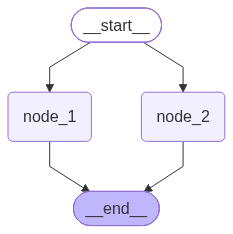

In [113]:
# 基本不用改，构建运行时并打印图结构
from IPython.display import display, Image

app = graph.compile()
display(Image(app.get_graph().draw_mermaid_png()))

In [114]:
# 测试图并打印结果
from langchain_core.messages import HumanMessage

# 修改这行代码修改输入消息
# message = HumanMessage(content="今天天气如何")
message = {"foo":[1]}
res = app.invoke({"foo":[1]})

print(res)
# for msg in res["messages"]:
#     msg.model_dump_json(indent = 2)

node value is [1]
{'foo': [2]}


[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


📊 图结构可视化


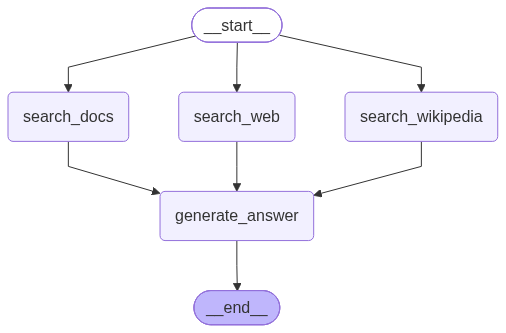


🚀 执行并行检索查询

📝 问题: 什么是 LangGraph？它有哪些主要功能？

⏳ 执行中...

📚 本地文档搜索完成
🌐 网络搜索完成
🔍 Wikipedia 搜索完成
📌 节点 [search_docs] 完成
📌 节点 [search_web] 完成
📌 节点 [search_wikipedia] 完成
✅ 答案生成完成
📌 节点 [generate_answer] 完成
📚 本地文档搜索完成
🌐 网络搜索完成
🔍 Wikipedia 搜索完成
✅ 答案生成完成

📋 最终结果

🔹 问题: 什么是 LangGraph？它有哪些主要功能？

🔹 检索到 3 个上下文源

🔹 答案:
**LangGraph** 是 LangChain 团队开发的用于构建复杂 AI 应用和智能体（Agent）的框架。它提供了构建 AI Agent 的完整解决方案，广泛应用于 RAG（检索增强生成）、对话系统和自动化工作流等场景。

**主要功能包括：**

1.  **核心组件管理**：
    *   **StateGraph（状态图）**：管理整个应用的状态。
    *   **Node（节点）**：执行具体的操作或逻辑。
    *   **Edge（边）**：定义节点之间的执行流程和连接关系。

2.  **高级流程控制**：
    *   支持**循环**和**分支**结构，能够处理复杂的、非线性的工作流逻辑。

3.  **状态与持久化**：
    *   提供**Checkpointer（检查点）**功能，用于保存状态历史，实现状态持久化和时间旅行（Time travel）调试。
    *   内置**记忆系统**，支持对话上下文的保存与调用。

4.  **智能体能力**：
    *   支持**多智能体协作**，多个 Agent 可以相互配合完成任务。
    *   支持**工具调用**，允许 Agent 使用外部工具。

5.  **人机协作**：
    *   支持在执行流程中引入人工干预和审批机制。


In [1]:
"""
LangGraph 并行执行完整示例
演示 Fan-out/Fan-in 模式和 Reducer 机制
"""

import operator
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage

# ========== 1. 状态定义 ==========


class State(TypedDict):
    """问答系统状态"""

    question: str  # 用户问题
    context: Annotated[list, operator.add]  # 检索到的上下文（支持并行追加）
    answer: str  # 生成的答案


# ========== 2. 初始化 LLM ==========

llm = ChatOpenAI(
    model="glm-4.7",
    api_key="d1de7475090740ebb6c887167a6a8b98.2WUSfYbmgQwYLKF4",
    base_url="https://open.bigmodel.cn/api/paas/v4/",  # 智谱OpenAI兼容地址，末尾斜杠不能丢
)


# ========== 3. 定义节点函数 ==========


def search_wikipedia(state: State):
    """
    模拟 Wikipedia 搜索
    实际应用中可使用: from langchain_community.document_loaders import WikipediaLoader
    """
    question = state["question"]

    # 模拟搜索结果
    wiki_result = f"""
    <Document source="Wikipedia">
    Wikipedia 搜索结果关于: {question}
    LangGraph 是 LangChain 团队开发的用于构建复杂 AI 应用的框架。
    它支持循环、分支、持久化等高级功能。
    主要特点包括：状态管理、检查点、人机协作等。
    </Document>
    """

    print(f"🔍 Wikipedia 搜索完成")
    return {"context": [wiki_result]}


def search_web(state: State):
    """
    模拟网络搜索
    实际应用中可使用: from langchain_community.tools import TavilySearchResults
    """
    question = state["question"]

    # 模拟搜索结果
    web_result = f"""
    <Document source="Web Search">
    网络搜索结果关于: {question}
    LangGraph 提供了构建 AI Agent 的完整解决方案。
    支持多智能体协作、工具调用、记忆系统等功能。
    广泛应用于 RAG、对话系统、自动化工作流等场景。
    </Document>
    """

    print(f"🌐 网络搜索完成")
    return {"context": [web_result]}


def search_docs(state: State):
    """
    模拟本地文档搜索
    实际应用中可使用向量数据库如 Chroma、FAISS 等
    """
    question = state["question"]

    # 模拟搜索结果
    docs_result = f"""
    <Document source="Local Docs">
    本地文档搜索结果关于: {question}
    LangGraph 的核心概念包括：
    1. StateGraph - 状态图，管理应用状态
    2. Node - 节点，执行具体操作
    3. Edge - 边，定义执行流程
    4. Checkpointer - 检查点，保存状态历史
    </Document>
    """

    print(f"📚 本地文档搜索完成")
    return {"context": [docs_result]}


def generate_answer(state: State):
    """基于检索到的上下文生成答案"""
    question = state["question"]
    context = state["context"]

    # 合并所有上下文
    combined_context = "\n\n".join(context)

    # 构建提示词
    system_prompt = f"""你是一个智能问答助手。请根据以下检索到的信息回答用户问题。

检索到的信息：
{combined_context}

要求：
1. 综合多个来源的信息
2. 给出准确、简洁的回答
3. 如果信息不足，请说明"""

    # 调用 LLM 生成答案
    response = llm.invoke(
        [SystemMessage(content=system_prompt), HumanMessage(content=question)]
    )

    print(f"✅ 答案生成完成")
    return {"answer": response.content}


# ========== 4. 构建图 ==========


def build_parallel_qa_graph():
    """构建并行检索问答图"""

    builder = StateGraph(State)

    # 添加节点
    builder.add_node("search_wikipedia", search_wikipedia)
    builder.add_node("search_web", search_web)
    builder.add_node("search_docs", search_docs)
    builder.add_node("generate_answer", generate_answer)

    # 并行执行：START 扇出到三个搜索节点
    builder.add_edge(START, "search_wikipedia")
    builder.add_edge(START, "search_web")
    builder.add_edge(START, "search_docs")

    # Fan-in：三个搜索节点汇聚到生成答案节点
    builder.add_edge("search_wikipedia", "generate_answer")
    builder.add_edge("search_web", "generate_answer")
    builder.add_edge("search_docs", "generate_answer")

    # 结束
    builder.add_edge("generate_answer", END)

    return builder.compile()


# ========== 5. 主程序 ==========

if __name__ == "__main__":
    # 构建图
    graph = build_parallel_qa_graph()

    # 可视化图结构
    print("=" * 50)
    print("📊 图结构可视化")
    print("=" * 50)

    try:
        from IPython.display import Image, display

        display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception:
        # 如果无法显示图片，打印 Mermaid 代码
        print(graph.get_graph().draw_mermaid())

    # 执行查询
    print("\n" + "=" * 50)
    print("🚀 执行并行检索查询")
    print("=" * 50)

    question = "什么是 LangGraph？它有哪些主要功能？"
    print(f"\n📝 问题: {question}\n")

    # 使用 stream 模式查看执行过程
    print("⏳ 执行中...\n")

    for step in graph.stream({"question": question}):
        for node_name, output in step.items():
            print(f"📌 节点 [{node_name}] 完成")

    # 获取最终结果
    result = graph.invoke({"question": question})

    print("\n" + "=" * 50)
    print("📋 最终结果")
    print("=" * 50)
    print(f"\n🔹 问题: {result['question']}")
    print(f"\n🔹 检索到 {len(result['context'])} 个上下文源")
    print(f"\n🔹 答案:\n{result['answer']}")
